## Superdense Coding: Encoding Table

Superdense coding lets a sender transmit **two classical bits** by sending only **one qubit**, using a pre-shared entangled pair. Starting from the shared Bell state $\vert\Phi^+\rangle$, the sender applies one of four single-qubit operations to *their* half of the pair, and each choice steers the joint system into a different Bell state.
This is a quantum communication protocol that securely sends classical bits of information by transmitting a smaller number of quantum bits. This protocol starts with the sender and receiver each having half of an entangled pair of qubits before the message needs to be sent.

**Initial Bell state:**

$$
\vert\Phi^+\rangle = \frac{\vert00\rangle + \vert11\rangle}{\sqrt{2}}
$$

| 2-Bit Message | Encoding Operation | Resulting Bell State |
|:---:|:---:|:---|
| `00` | $I$ (identity — do nothing) | $\vert\Phi^+\rangle = \dfrac{\vert00\rangle + \vert11\rangle}{\sqrt{2}}$ |
| `01` | $Z$ | $\vert\Phi^-\rangle = \dfrac{\vert00\rangle - \vert11\rangle}{\sqrt{2}}$ |
| `10` | $X$ | $\vert\Psi^+\rangle = \dfrac{\vert01\rangle + \vert10\rangle}{\sqrt{2}}$ |
| `11` | $Z$ then $X$ | $\vert\Psi^-\rangle = \dfrac{\vert01\rangle - \vert10\rangle}{\sqrt{2}}$ |

### How each case works

- **`00`** — Apply the identity gate (do nothing). The pair stays in the same Bell state it started in, $\vert\Phi^+\rangle$.
- **`01`** — Apply a $Z$ gate to the sender's qubit. This flips the relative sign between the $\vert00\rangle$ and $\vert11\rangle$ terms, moving the pair into $\vert\Phi^-\rangle$.
- **`10`** — Apply an $X$ gate to the sender's qubit. This flips the sender's qubit value in both terms, moving the pair into $\vert\Psi^+\rangle$.
- **`11`** — Apply a $Z$ gate followed by an $X$ gate. This combines both effects, landing the pair in the fourth and final Bell state, $\vert\Psi^-\rangle$.

Each of the four operations maps the shared pair to one of the four **mutually distinguishable** Bell states. When the receiver later measures both qubits jointly (in the Bell basis), they can tell exactly which of the four states — and therefore which 2-bit message — was sent, even though only one physical qubit was transmitted.

## Superdense Coding: Decoding the Message

### The Problem with a Direct Measurement

To recover the sender's message, the receiver needs to determine which of the four Bell basis states the entangled pair is in. A plain $Z$-basis measurement on both qubits only reveals whether the pair is **correlated** (same outcome) or **anti-correlated** (opposite outcomes) — that narrows things down to two possibilities, but it can't distinguish all four messages on its own.

### Decoding Before Measuring

To fully recover the message, the receiver must **disentangle** the pair first, by applying the reverse of whatever operations originally created the entanglement. This converts the Bell state back into a pair of qubits in independent, well-defined basis states. Once disentangled, a standard measurement deterministically reveals the sender's exact 2-bit message (setting aside real-world noise and error sources).

### Why Two Qubits Are Required

Superdense coding transmits two classical bits by physically sending only one qubit — but the protocol still relies on **both** qubits of the entangled pair. Information can't be extracted from either qubit alone; the receiver needs both to decode the message.

### Security Implications

This two-qubit requirement is what makes superdense coding inherently secure:

- If an eavesdropper intercepts the transmitted qubit and measures it, the result is completely random and reveals nothing about the encoded message.
- The message only becomes recoverable when the intercepted qubit is combined with its entangled partner.

### No Faster-Than-Light Communication

Although the sender's encoding operation has an instantaneous effect on the entangled state (regardless of the physical distance between the pair), this doesn't allow faster-than-light communication:

- The receiver can't decode anything until the sender's qubit physically arrives.
- Without that qubit, no information has actually been transferred — entanglement alone doesn't transmit information.

This keeps superdense coding fully consistent with known physics.

### A Bit of History

The superdense coding protocol was first proposed in the 1970s, though it wasn't published until 1992, and was experimentally demonstrated in 1996 using entangled photons. As far as scientific timelines go, that's a remarkably simple and elegant protocol that's only a few decades old — a reminder that there may be other equally elegant quantum algorithms still waiting to be discovered.

In [31]:
from qiskit import *
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from qiskit_aer import Aer

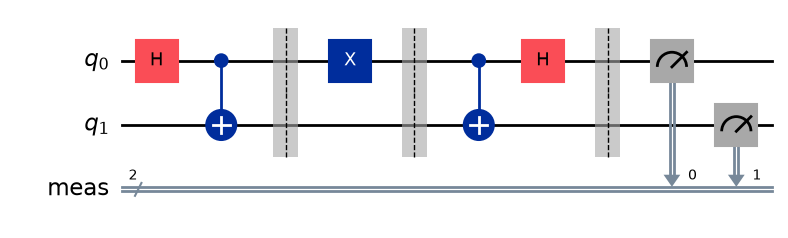

In [32]:
circuit = QuantumCircuit(2)
#Prepare the Bell state and distribute qubits.
circuit.h(0)
circuit.cx(0,1)

circuit.barrier() #Guarantees all operations before the barrier are completed.

# Python match expression to encode a message and transmit the qubit to be sent.
match message := '10': # The message.
    case '00':
        circuit.id(0)
    case '01':
        circuit.z(0)
    case '10':
        circuit.x(0)
    case '11':
        circuit.z(0)
        circuit.x(0)

circuit.barrier()

# Decode message.
circuit.cx(0,1)
circuit.h(0)

# Measure the qubits to read the message
circuit.measure_all()
circuit.draw(output='mpl')

The circuit for Superdense Coding begins by creating an entangled Bell state pair. Then, encode the message by applying an operation to the first qubit, and finally, the receiver performs a Bell state measurement to decode and receive the message.

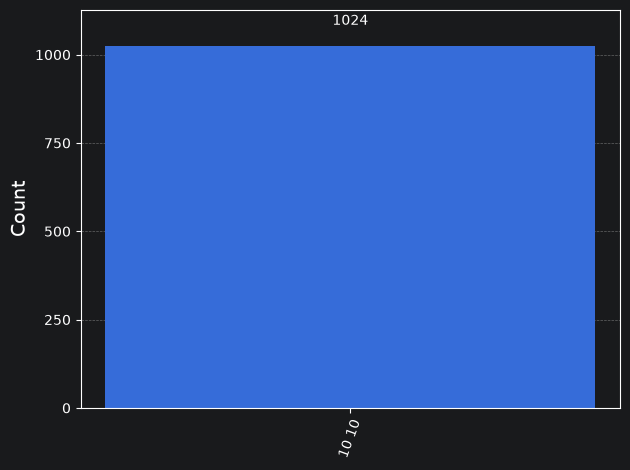

In [33]:
circuit.measure_all()
simulator = Aer.get_backend('qasm_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots=1024).result()
plot_histogram(result.get_counts())

Superdense coding is a quantum algorithm that produces a deterministic result. Becuase `match message := '10':` # The receiver is alwayse able to decode the correct result `10 on the histogram`